# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective

### Setup

In [1]:
from src.eval import plot_temperature_triptych
from src.dataset import load_mnist_tensor

# MNIST Dataset

In [2]:
dataset="mnist"

sigma=1.0
n_bins=220
n_samples=4
k=4.0
n_replicas=3

In [3]:
# def apply_temperature(x, k=1.0):
#     """x in [0,1]. k>1 sharpens, k<1 flattens."""
#     x = x.clamp(1e-6, 1 - 1e-6)  # avoid log(0)
#     logits = torch.log(x / (1 - x))  # inverse sigmoid
#     logits = logits * k              # scale by temperature
#     return torch.sigmoid(logits)     # back to [0,1]

# x = load_mnist_tensor(train=False, normalize_to_minus1_1=False)

# ks = np.linspace(1.0, k, n_replicas)
# fig, axes = plt.subplots(n_samples, len(ks), figsize=(len(ks) * 2, n_samples*2))

# for row in range(n_samples):
#     for col, k in enumerate(ks):
#         img = apply_temperature(x[row, 0], k=k)
#         axes[row, col].imshow(img.numpy(), cmap="gray", vmin=0, vmax=1)
#         axes[row, col].axis("off")
#         if row == 0:
#             axes[row, col].set_title(f"k={k}")

# plt.tight_layout()
# plt.show()

In [4]:
# _ = plot_temperature_triptych(dataset_name=dataset, sigma=sigma, n_bins=n_bins, n_samples=n_samples, k=k, replica_swaps=False)

In [5]:
# _ = plot_temperature_triptych(dataset_name=dataset, sigma=sigma, n_bins=n_bins, n_samples=n_samples, k=k, replica_swaps=True)

# Composed Dataset

In [6]:
dataset="composed"

Accept analytical: 0.883 non-analytical: 0.739


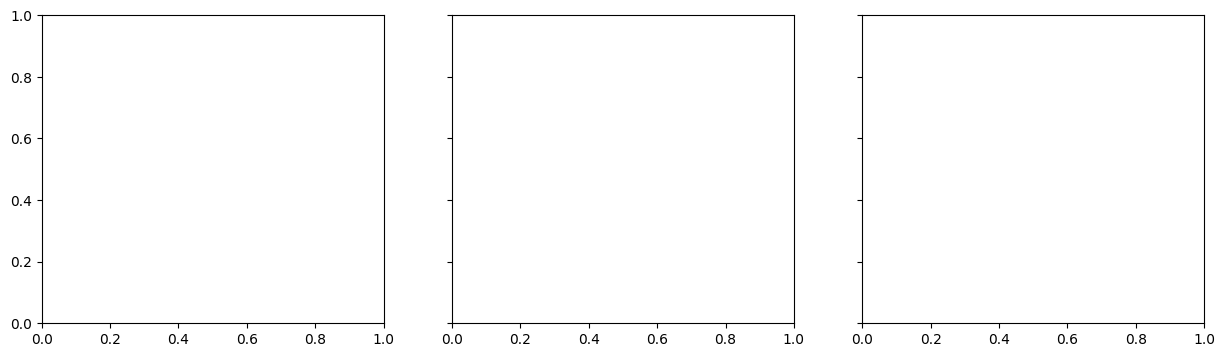

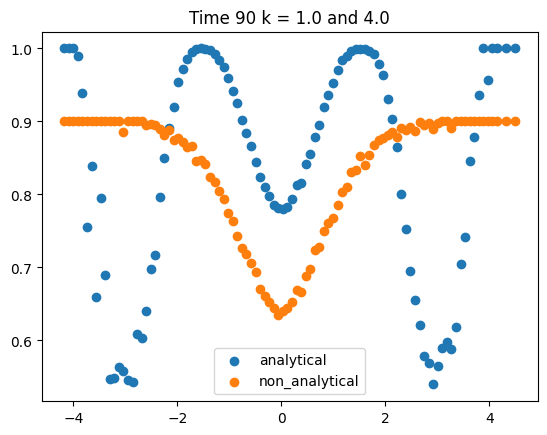

Time 90 xs 0.00 xt -0.00 swap 0.88 
Accept analytical: 0.963 non-analytical: 0.778


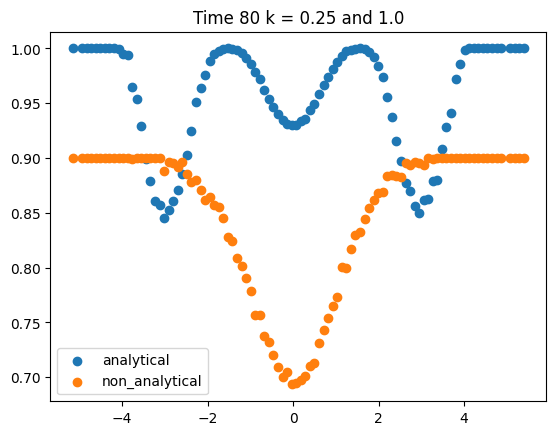

Time 80 xs 0.01 xt 0.01 swap 0.96 
Accept analytical: 0.861 non-analytical: 0.786


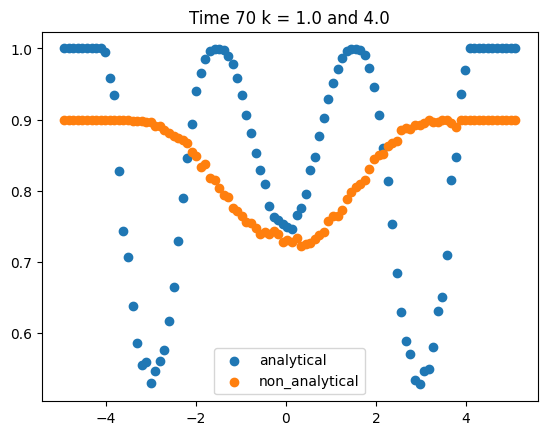

Time 70 xs 0.01 xt 0.02 swap 0.86 
Accept analytical: 0.955 non-analytical: 0.839


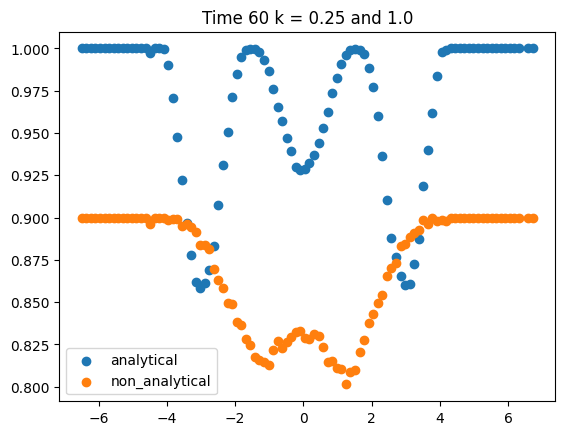

Time 60 xs 0.02 xt 0.03 swap 0.95 
Accept analytical: 0.836 non-analytical: 0.830


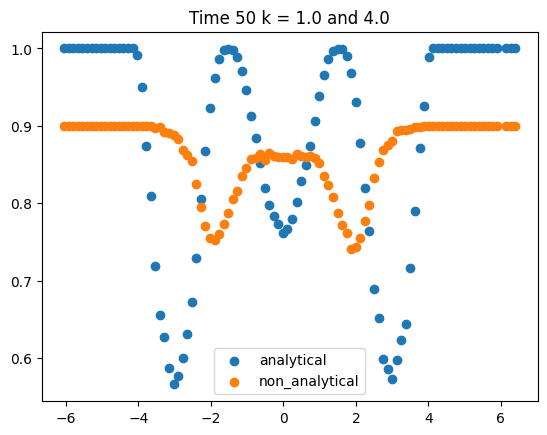

Time 50 xs 0.03 xt 0.03 swap 0.84 
Accept analytical: 0.962 non-analytical: 0.860


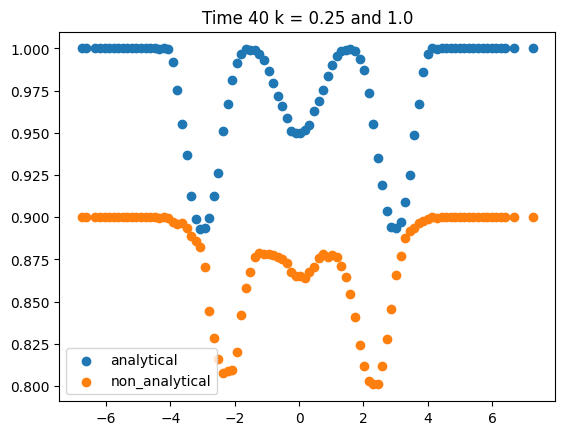

Time 40 xs 0.03 xt 0.04 swap 0.96 
Accept analytical: 0.895 non-analytical: 0.820


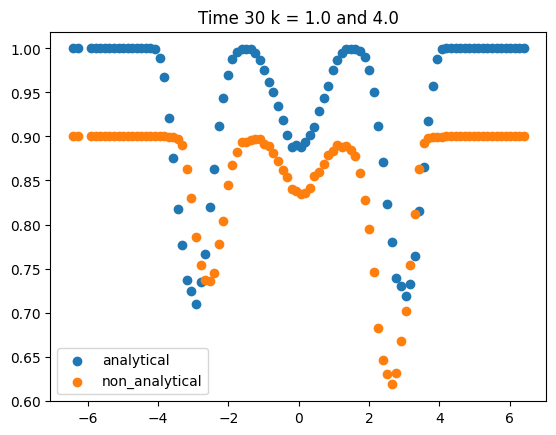

Time 30 xs 0.04 xt 0.05 swap 0.90 
Accept analytical: 0.975 non-analytical: 0.867


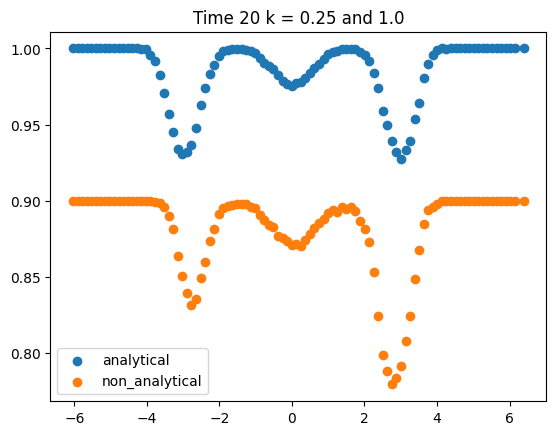

Time 20 xs 0.05 xt 0.05 swap 0.97 


<Figure size 640x480 with 0 Axes>

In [7]:
_ = plot_temperature_triptych(dataset_name=dataset, sigma=sigma, n_bins=n_bins,n_replicas=n_replicas,n_samples=n_samples, k=k, replica_swaps=True, analytical=True)

Time 90 xs -0.00 xt -0.01 swap 0.74 
Time 80 xs -0.01 xt 0.01 swap 0.79 
Time 70 xs 0.02 xt 0.01 swap 0.79 
Time 60 xs 0.04 xt 0.02 swap 0.85 
Time 50 xs 0.01 xt 0.03 swap 0.82 
Time 40 xs 0.01 xt 0.06 swap 0.86 
Time 30 xs 0.04 xt 0.06 swap 0.82 
Time 20 xs 0.16 xt 0.02 swap 0.86 


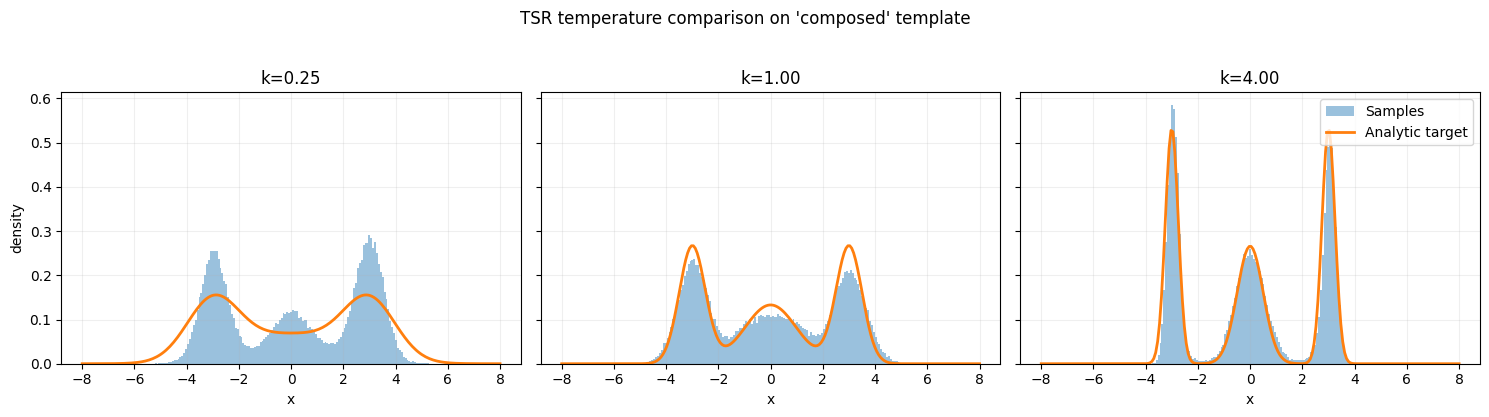

In [8]:
_ = plot_temperature_triptych(dataset_name=dataset, sigma=sigma, n_bins=n_bins, n_replicas=n_replicas, n_samples=n_samples, k=k, replica_swaps=True, analytical=False)

In [9]:
# _ = plot_temperature_triptych(dataset_name=dataset, sigma=sigma, n_bins=n_bins,n_replicas=n_replicas, n_samples=n_samples, k=k, replica_swaps=False)